In [1]:
import numpy as np
import pandas as pd
import nltk
import string
import matplotlib.pyplot as plt
import seaborn as sns
import os 
import re
import csv
from sklearn.feature_extraction.text import CountVectorizer
%matplotlib inline
#nltk.download()

In [2]:
pip install odfpy

Note: you may need to restart the kernel to use updated packages.


In [3]:
os.chdir("C:\\Users\\mjnpo\\My Python Stuff\\Problem Set 1 from EC9D8")

In [4]:
pwd

'C:\\Users\\mjnpo\\My Python Stuff\\Problem Set 1 from EC9D8'

In [5]:
ls

 Volume in drive C is Windows
 Volume Serial Number is 4AEF-23B4

 Directory of C:\Users\mjnpo\My Python Stuff\Problem Set 1 from EC9D8

23/06/2026  09:30    <DIR>          .
23/06/2026  09:30    <DIR>          ..
23/06/2026  09:30    <DIR>          .ipynb_checkpoints
22/06/2026  23:41            68,641 EC9D8 Problem Set 1.ipynb
22/06/2026  17:11           868,471 updated_microdata_sample_codes2.ods
22/06/2026  16:56        38,590,431 upload-publicmicrodatateachingsample.csv
               3 File(s)     39,527,543 bytes
               3 Dir(s)  562,673,270,784 bytes free


In [6]:
df = pd.read_csv('upload-publicmicrodatateachingsample.csv',delimiter=",")

In [7]:
df

,resident_id_m,approx_social_grade,country_of_birth_3a,economic_activity_status_10m,ethnic_group_tb_6a,health_in_general,hh_families_type_6a,hours_per_week_worked,in_full_time_education,industry_10a,iol22cd,legal_partnership_status_6a,occupation_10a,region,religion_tb,residence_type,resident_age_7d,sex,usual_short_student
0,PTS000000588097,4,1,1,4,1,4,4,2,4,-8,1,5,E12000003,2,1,4,2,1
1,PTS000000000320,-8,1,5,4,2,1,-8,2,7,-8,1,2,E12000005,2,1,7,2,1
2,PTS000000397448,-8,2,5,4,2,1,-8,2,7,-8,1,3,E12000002,2,1,7,2,1
3,PTS000000082442,-8,1,5,4,3,2,-8,2,8,-8,2,8,E12000006,2,1,7,1,1
4,PTS000000016066,4,1,8,4,2,1,-8,2,9,-8,1,9,E12000002,1,1,2,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
604346,PTS000000166524,-8,2,6,4,1,-8,-8,1,-8,-8,1,-8,E12000006,9,2,2,2,1
604347,PTS000000246489,2,1,1,4,2,2,3,2,5,-8,2,7,E12000002,2,1,6,1,1
604348,PTS000000177162,-8,1,9,4,2,-8,-8,2,-8,-8,1,-8,E12000001,2,2,6,1,1
604349,PTS000000377217,-8,1,6,4,1,-8,-8,1,7,-8,1,5,E12000001,1,2,2,2,1


In [8]:
print("Header row:", df.columns.tolist())

Header row: ['resident_id_m', 'approx_social_grade', 'country_of_birth_3a', 'economic_activity_status_10m', 'ethnic_group_tb_6a', 'health_in_general', 'hh_families_type_6a', 'hours_per_week_worked', 'in_full_time_education', 'industry_10a', 'iol22cd', 'legal_partnership_status_6a', 'occupation_10a', 'region', 'religion_tb', 'residence_type', 'resident_age_7d', 'sex', 'usual_short_student']


In [9]:
names_df = pd.read_excel("updated_microdata_sample_codes2.ods", sheet_name = "Samples_variable_list")

In [10]:
codes_df = pd.read_excel("updated_microdata_sample_codes2.ods", sheet_name = "Microdata_sample_codes", skiprows=5)

In [11]:
print("\n📊 Shape of dataset:", df.shape)

print("\n📑 Column names:")
print(df.columns.tolist())

print("\n📋 Data types:")
print(df.dtypes)

print("\n📊 Missing values per column:")
print(df.isna().sum())

print("\n📋 Unique values:")
print(df.nunique())



📊 Shape of dataset: (604351, 19)

📑 Column names:
['resident_id_m', 'approx_social_grade', 'country_of_birth_3a', 'economic_activity_status_10m', 'ethnic_group_tb_6a', 'health_in_general', 'hh_families_type_6a', 'hours_per_week_worked', 'in_full_time_education', 'industry_10a', 'iol22cd', 'legal_partnership_status_6a', 'occupation_10a', 'region', 'religion_tb', 'residence_type', 'resident_age_7d', 'sex', 'usual_short_student']

📋 Data types:
resident_id_m                   object
approx_social_grade              int64
country_of_birth_3a              int64
economic_activity_status_10m     int64
ethnic_group_tb_6a               int64
health_in_general                int64
hh_families_type_6a              int64
hours_per_week_worked            int64
in_full_time_education           int64
industry_10a                     int64
iol22cd                         object
legal_partnership_status_6a      int64
occupation_10a                   int64
region                          object
religio

In [12]:
print(df["region"].value_counts())

region
E12000008    94344
E12000007    89489
E12000002    75080
E12000006    64258
E12000005    60231
E12000009    57815
E12000003    55469
E12000004    49440
W92000004    31458
E12000001    26767
Name: count, dtype: int64


In [13]:
codes_df

,Microdata_variable_name,Classification_mnemonic,Category_code,Category_label,Classification_label,Similar_variable_in_2011,Data_types,Data_length,Public_data,Safeguarded_household_data,Safeguarded_region_data,Safeguarded_la_data,Secure_household_data,Secure_individual_data
0,66_plus_hh,66_plus_hh,-8,Does not apply,Households with people aged 66 years and over ...,PENHUK11,int,2,no,no,yes,no,yes,yes
1,66_plus_hh,66_plus_hh,0,Female: Aged 66 to 74 years,Households with people aged 66 years and over ...,PENHUK11,int,2,no,no,yes,no,yes,yes
2,66_plus_hh,66_plus_hh,1,Female: Aged 75 to 84 years,Households with people aged 66 years and over ...,PENHUK11,int,2,no,no,yes,no,yes,yes
3,66_plus_hh,66_plus_hh,2,Female: Aged 85 years and over,Households with people aged 66 years and over ...,PENHUK11,int,2,no,no,yes,no,yes,yes
4,66_plus_hh,66_plus_hh,3,Male: Aged 66 to 74 years,Households with people aged 66 years and over ...,PENHUK11,int,2,no,no,yes,no,yes,yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
33335,year_of_arrival_in_country,year_of_arrival_in_country,2017,2017,Year of arrival in UK (117 categories),YRARR_YEAR,smallint,9,no,no,no,no,yes,yes
33336,year_of_arrival_in_country,year_of_arrival_in_country,2018,2018,Year of arrival in UK (117 categories),YRARR_YEAR,smallint,9,no,no,no,no,yes,yes
33337,year_of_arrival_in_country,year_of_arrival_in_country,2019,2019,Year of arrival in UK (117 categories),YRARR_YEAR,smallint,9,no,no,no,no,yes,yes
33338,year_of_arrival_in_country,year_of_arrival_in_country,2020,2020,Year of arrival in UK (117 categories),YRARR_YEAR,smallint,9,no,no,no,no,yes,yes


In [14]:

codes_df = codes_df.rename(columns={'Unnamed: 0': 'Microdata_variable_name', 'Unnamed: 2': 'Category_code', 'Unnamed: 3': 'Category_label'})


In [15]:
print(codes_df[codes_df["Microdata_variable_name"] == "region"][["Microdata_variable_name", "Category_code", "Category_label"]])

      Microdata_variable_name Category_code                    Category_label
31275                  region     E12000001                        North East
31276                  region     E12000002                        North West
31277                  region     E12000003          Yorkshire and The Humber
31278                  region     E12000004                     East Midlands
31279                  region     E12000005                     West Midlands
31280                  region     E12000006                   East of England
31281                  region     E12000007                            London
31282                  region     E12000008                        South East
31283                  region     E12000009                        South West
31284                  region     N99999999  Does not apply: Northern Ireland
31285                  region     S99999999          Does not apply: Scotland
31286                  region     W92000004                     

In [16]:
print(codes_df[codes_df["Microdata_variable_name"] == "country_of_birth_3a"][["Microdata_variable_name", "Category_code", "Category_label"]])

    Microdata_variable_name Category_code       Category_label
675     country_of_birth_3a            -8       Does not apply
676     country_of_birth_3a             1       Born in the UK
677     country_of_birth_3a             2  Born outside the UK


In [17]:
print(codes_df[codes_df["Microdata_variable_name"] == "ethnic_group_tb_6a"][["Microdata_variable_name", "Category_code", "Category_label"]])

      Microdata_variable_name Category_code  \
13152      ethnic_group_tb_6a            -8   
13153      ethnic_group_tb_6a             1   
13154      ethnic_group_tb_6a             2   
13155      ethnic_group_tb_6a             3   
13156      ethnic_group_tb_6a             4   
13157      ethnic_group_tb_6a             5   

                                          Category_label  
13152                                     Does not apply  
13153                Asian, Asian British or Asian Welsh  
13154  Black, Black British, Black Welsh, Caribbean o...  
13155                    Mixed or Multiple ethnic groups  
13156                                              White  
13157                                 Other ethnic group  


In [18]:
print(codes_df[codes_df["Microdata_variable_name"] == "religion_tb"][["Microdata_variable_name", "Category_code", "Category_label"]])

      Microdata_variable_name Category_code  Category_label
31433             religion_tb            -8  Does not apply
31434             religion_tb             1     No religion
31435             religion_tb             2       Christian
31436             religion_tb             3        Buddhist
31437             religion_tb             4           Hindu
31438             religion_tb             5          Jewish
31439             religion_tb             6          Muslim
31440             religion_tb             7            Sikh
31441             religion_tb             8  Other religion
31442             religion_tb             9    Not answered


In [19]:
print("Dimensions master:")
print(df.shape)
print("Dimensions using:")
print(codes_df.shape)

Dimensions master:
(604351, 19)
Dimensions using:
(33340, 14)


In [20]:
def add_labels(df, codes_df, variable):
    mapping = codes_df[codes_df["Microdata_variable_name"] == variable][
        ["Category_code", "Category_label"]
    ].copy()
    
    # ✅ Force both to same type before merging
    mapping["Category_code"] = mapping["Category_code"].astype(df[variable].dtype)
    
    mapping = mapping.rename(columns={
        "Category_code": variable,
        "Category_label": variable + "_label"
    })
    
    merged = pd.merge(df, mapping, on=variable, how="left")
    return merged

# Re-run loop
Variables = ["region", "country_of_birth_3a", "ethnic_group_tb_6a", "religion_tb"]
for var in Variables:
    df = add_labels(df, codes_df, var)

# Verify all 4 label columns exist and have no NaN
for var in Variables:
    print(f"{var}_label nulls: {df[var + '_label'].isna().sum()}")


region_label nulls: 0
country_of_birth_3a_label nulls: 0
ethnic_group_tb_6a_label nulls: 0
religion_tb_label nulls: 0


In [21]:
df

,resident_id_m,approx_social_grade,country_of_birth_3a,economic_activity_status_10m,ethnic_group_tb_6a,health_in_general,hh_families_type_6a,hours_per_week_worked,in_full_time_education,industry_10a,...,region,religion_tb,residence_type,resident_age_7d,sex,usual_short_student,region_label,country_of_birth_3a_label,ethnic_group_tb_6a_label,religion_tb_label
0,PTS000000588097,4,1,1,4,1,4,4,2,4,...,E12000003,2,1,4,2,1,Yorkshire and The Humber,Born in the UK,White,Christian
1,PTS000000000320,-8,1,5,4,2,1,-8,2,7,...,E12000005,2,1,7,2,1,West Midlands,Born in the UK,White,Christian
2,PTS000000397448,-8,2,5,4,2,1,-8,2,7,...,E12000002,2,1,7,2,1,North West,Born outside the UK,White,Christian
3,PTS000000082442,-8,1,5,4,3,2,-8,2,8,...,E12000006,2,1,7,1,1,East of England,Born in the UK,White,Christian
4,PTS000000016066,4,1,8,4,2,1,-8,2,9,...,E12000002,1,1,2,2,1,North West,Born in the UK,White,No religion
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
604346,PTS000000166524,-8,2,6,4,1,-8,-8,1,-8,...,E12000006,9,2,2,2,1,East of England,Born outside the UK,White,Not answered
604347,PTS000000246489,2,1,1,4,2,2,3,2,5,...,E12000002,2,1,6,1,1,North West,Born in the UK,White,Christian
604348,PTS000000177162,-8,1,9,4,2,-8,-8,2,-8,...,E12000001,2,2,6,1,1,North East,Born in the UK,White,Christian
604349,PTS000000377217,-8,1,6,4,1,-8,-8,1,7,...,E12000001,1,2,2,2,1,North East,Born in the UK,White,No religion


In [22]:
print(df["region_label"].value_counts())

region_label
South East                  94344
London                      89489
North West                  75080
East of England             64258
West Midlands               60231
South West                  57815
Yorkshire and The Humber    55469
East Midlands               49440
Wales                       31458
North East                  26767
Name: count, dtype: int64


In [23]:
print(df["region_label"].value_counts(normalize = True))

region_label
South East                  0.156108
London                      0.148075
North West                  0.124232
East of England             0.106326
West Midlands               0.099662
South West                  0.095665
Yorkshire and The Humber    0.091783
East Midlands               0.081807
Wales                       0.052053
North East                  0.044290
Name: proportion, dtype: float64


In [24]:
print(df["country_of_birth_3a_label"].value_counts())

country_of_birth_3a_label
Born in the UK         496377
Born outside the UK    100985
Does not apply           6989
Name: count, dtype: int64


In [25]:
print(df["country_of_birth_3a_label"].value_counts(normalize=True))

country_of_birth_3a_label
Born in the UK         0.821339
Born outside the UK    0.167097
Does not apply         0.011564
Name: proportion, dtype: float64


In [26]:
print(df["religion_tb_label"].value_counts())

religion_tb_label
Christian         275536
No religion       222290
Muslim             38728
Not answered       36282
Hindu              10283
Does not apply      6989
Sikh                5279
Other religion      3499
Buddhist            2789
Jewish              2676
Name: count, dtype: int64


In [27]:
print(df["religion_tb_label"].value_counts(normalize = True))

religion_tb_label
Christian         0.455920
No religion       0.367816
Muslim            0.064082
Not answered      0.060035
Hindu             0.017015
Does not apply    0.011564
Sikh              0.008735
Other religion    0.005790
Buddhist          0.004615
Jewish            0.004428
Name: proportion, dtype: float64


In [28]:
print(df["ethnic_group_tb_6a_label"].value_counts())

ethnic_group_tb_6a_label
White                                                      487868
Asian, Asian British or Asian Welsh                         55705
Black, Black British, Black Welsh, Caribbean or African     24068
Mixed or Multiple ethnic groups                             17066
Other ethnic group                                          12655
Does not apply                                               6989
Name: count, dtype: int64


In [33]:
print(df["ethnic_group_tb_6a_label"].value_counts(normalize = True))

ethnic_group_tb_6a_label
White                                                      0.807259
Asian, Asian British or Asian Welsh                        0.092173
Black, Black British, Black Welsh, Caribbean or African    0.039825
Mixed or Multiple ethnic groups                            0.028239
Other ethnic group                                         0.020940
Does not apply                                             0.011564
Name: proportion, dtype: float64


<function matplotlib.pyplot.show(close=None, block=None)>

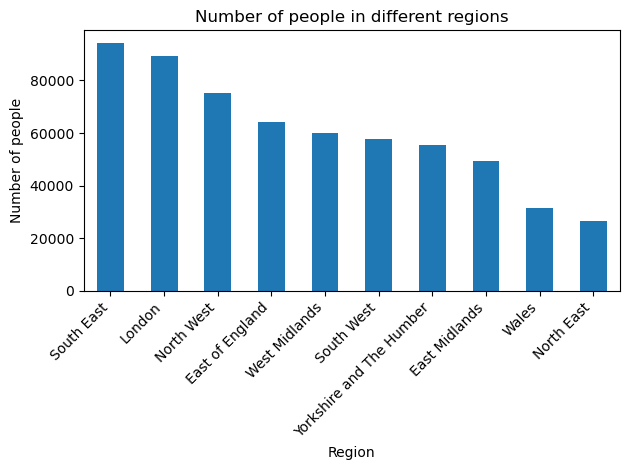

In [49]:
df["region_label"].value_counts().plot(kind = "bar")
plt.title("Number of people in different regions")
plt.xlabel("Region")
plt.ylabel("Number of people")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

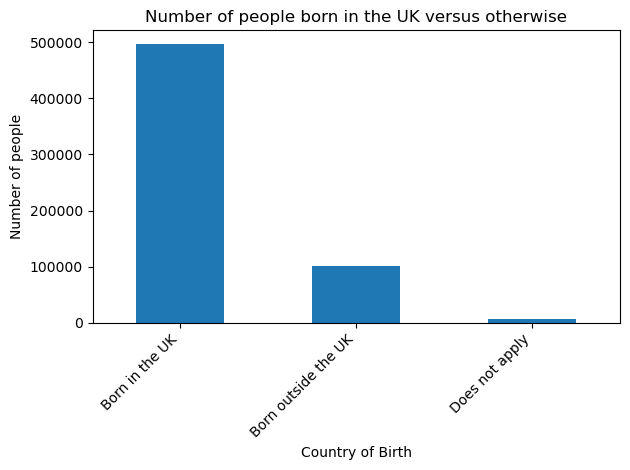

In [50]:
df["country_of_birth_3a_label"].value_counts().plot(kind = "bar")
plt.title("Number of people born in the UK versus otherwise")
plt.xlabel("Country of Birth")
plt.ylabel("Number of people")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

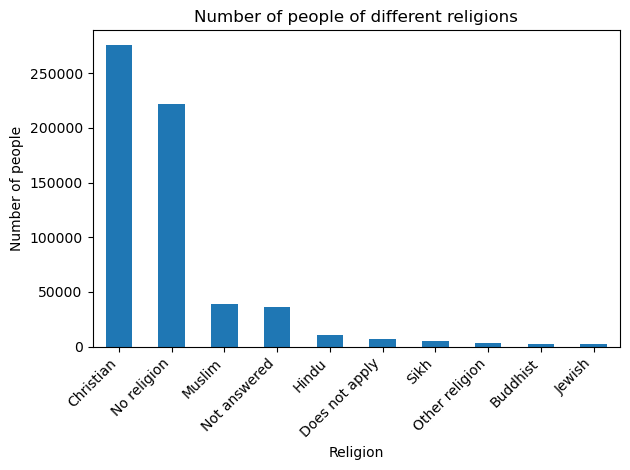

In [52]:
df["religion_tb_label"].value_counts().plot(kind = "bar")
plt.title("Number of people of different religions")
plt.xlabel("Religion")
plt.ylabel("Number of people")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

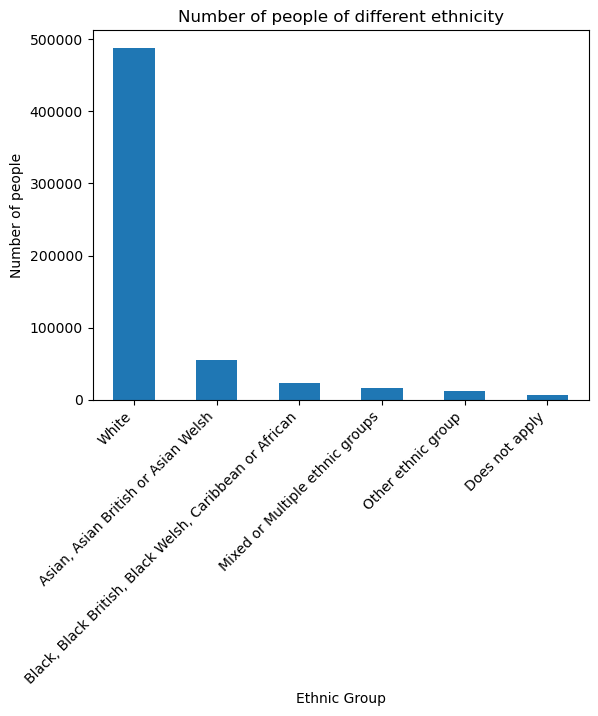

In [55]:
df["ethnic_group_tb_6a_label"].value_counts().plot(kind = "bar")
plt.title("Number of people of different ethnicity")
plt.xlabel("Ethnic Group")
plt.ylabel("Number of people")
plt.xticks(rotation=45, ha='right')
plt.show